In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
tf.random.set_seed(42)
np.random.seed(42)

In [42]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [43]:
print("\nDataset Information")
print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("\nChecking for missing values...")
print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in X_test:", np.isnan(X_test).sum())


Dataset Information
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)

Checking for missing values...
Missing values in X_train: 0
Missing values in X_test: 0


In [44]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
    'Coat', 'Sandal', 'Shirt', 'Sneaker',
    'Bag', 'Ankle boot'
]
print("Number of classes:", len(class_names))

Number of classes: 10


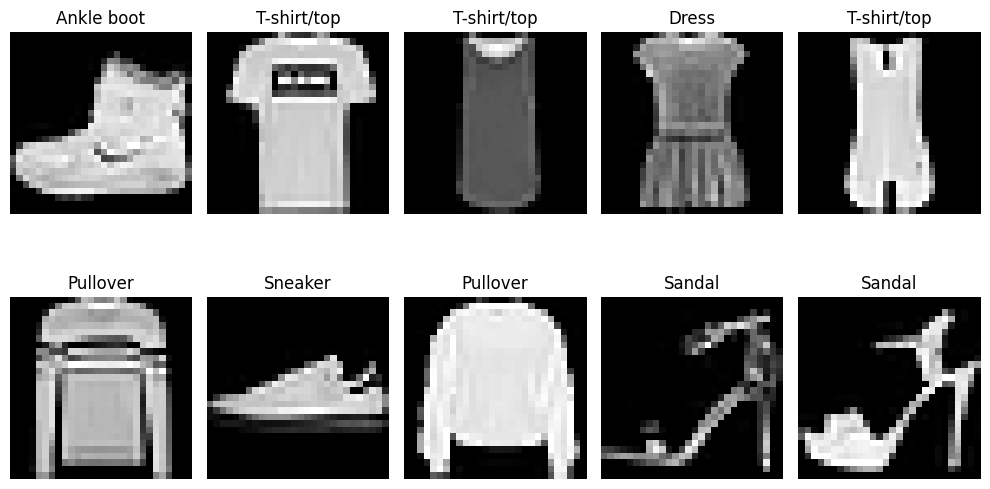

In [45]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [47]:
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8056 - loss: 0.5490 - val_accuracy: 0.8467 - val_loss: 0.4110
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8496 - loss: 0.4098 - val_accuracy: 0.8568 - val_loss: 0.3812
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8619 - loss: 0.3769 - val_accuracy: 0.8613 - val_loss: 0.3643
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8720 - loss: 0.3518 - val_accuracy: 0.8707 - val_loss: 0.3543
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8747 - loss: 0.3376 - val_accuracy: 0.8683 - val_loss: 0.3508
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8810 - loss: 0.3219 - val_accuracy: 0.8700 - val_loss: 0.3566
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8834 - loss: 0.3127 - val_accuracy: 0.8695 - val_loss: 0.3578
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8870 - loss: 0.304

In [51]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nBaseline Model Results")
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Loss:", round(test_loss, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8695 - loss: 0.3665

Baseline Model Results
Test Accuracy: 0.8695
Test Loss: 0.3665


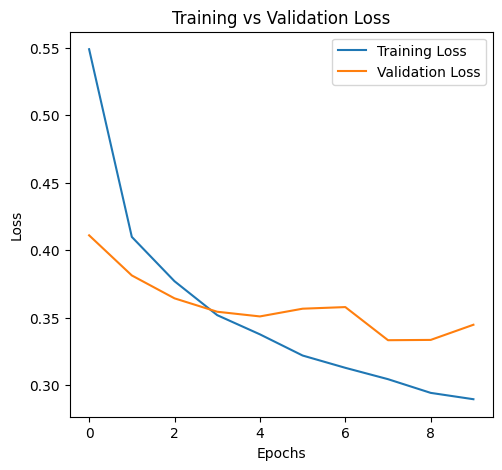

In [52]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

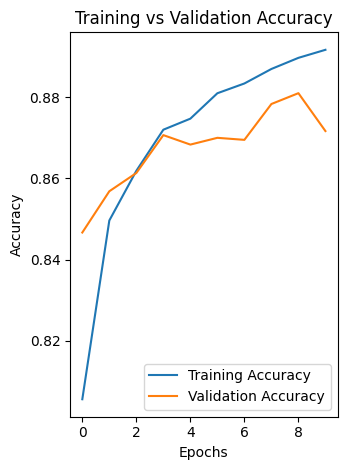

In [53]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [54]:

model_exp1 = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation='sigmoid'),
    Dropout(0.2),

    Dense(64, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model_exp1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp1 = model_exp1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7747 - loss: 0.6746 - val_accuracy: 0.8395 - val_loss: 0.4423
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8454 - loss: 0.4273 - val_accuracy: 0.8540 - val_loss: 0.3935
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8589 - loss: 0.3882 - val_accuracy: 0.8622 - val_loss: 0.3746
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8679 - loss: 0.3636 - val_accuracy: 0.8688 - val_loss: 0.3595
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8744 - loss: 0.3458 - val_accuracy: 0.8722 - val_loss: 0.3466
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8774 - loss: 0.3322 - val_accuracy: 0.8738 - val_loss: 0.3373
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8832 - loss: 0.3188 - val_accuracy: 0.8737 - val_loss: 0.3412
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8868 - loss: 0.3093

In [55]:
model_exp2 = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

model_exp2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_exp2 = model_exp2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7506 - loss: 0.6693 - val_accuracy: 0.8163 - val_loss: 0.5353
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8009 - loss: 0.5658 - val_accuracy: 0.8238 - val_loss: 0.4719
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8078 - loss: 0.5386 - val_accuracy: 0.8413 - val_loss: 0.4590
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8145 - loss: 0.5256 - val_accuracy: 0.8282 - val_loss: 0.4759
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8199 - loss: 0.5131 - val_accuracy: 0.8360 - val_loss: 0.4539
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8219 - loss: 0.5093 - val_accuracy: 0.8532 - val_loss: 0.4368
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8276 - loss: 0.4926 - val_accuracy: 0.8453 - val_loss: 0.4486
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8266 - loss: 0

In [56]:
loss0, acc0 = model.evaluate(X_test, y_test, verbose=0)
loss1, acc1 = model_exp1.evaluate(X_test, y_test, verbose=0)
loss2, acc2 = model_exp2.evaluate(X_test, y_test, verbose=0)

print("\n========================================")
print("FINAL COMPARISON")
print("========================================")

print(f"{'Experiment':<35} {'Accuracy':>10} {'Loss':>10}")
print("-" * 60)

print(f"{'Baseline (ReLU, lr=0.001)':<35} {acc0:>10.4f} {loss0:>10.4f}")
print(f"{'Exp1 (Sigmoid, lr=0.001)':<35} {acc1:>10.4f} {loss1:>10.4f}")
print(f"{'Exp2 (ReLU, lr=0.01)':<35} {acc2:>10.4f} {loss2:>10.4f}")


FINAL COMPARISON
Experiment                            Accuracy       Loss
------------------------------------------------------------
Baseline (ReLU, lr=0.001)               0.8695     0.3665
Exp1 (Sigmoid, lr=0.001)                0.8738     0.3517
Exp2 (ReLU, lr=0.01)                    0.8419     0.4703


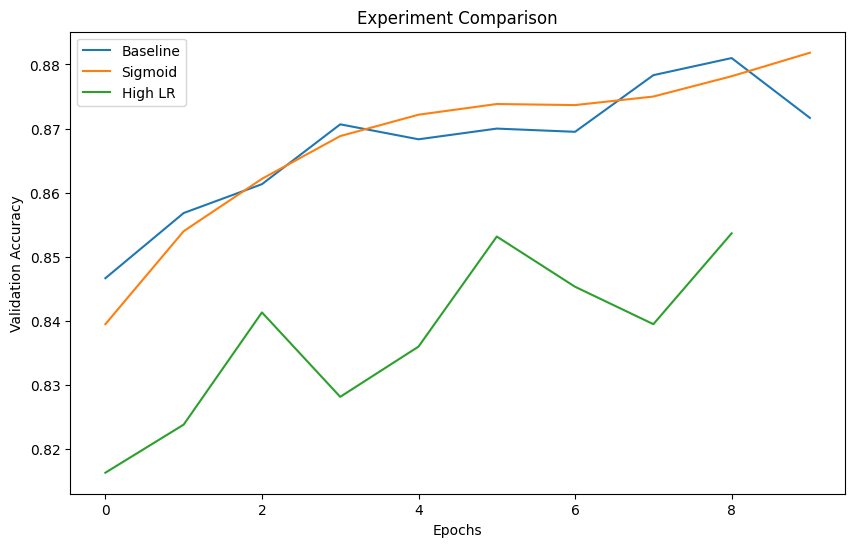

In [57]:
plt.figure(figsize=(10,6))

plt.plot(history.history['val_accuracy'], label='Baseline')
plt.plot(history_exp1.history['val_accuracy'], label='Sigmoid')
plt.plot(history_exp2.history['val_accuracy'], label='High LR')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Experiment Comparison")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Prediction Example
Predicted: Ankle boot
Actual: Ankle boot


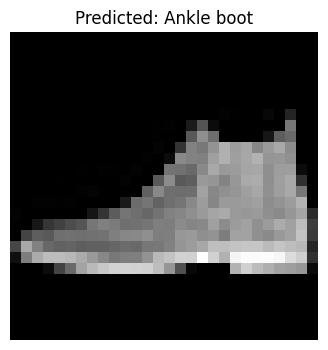

In [58]:
predictions = model.predict(X_test)

predicted_label = np.argmax(predictions[0])
actual_label = y_test[0]

print("\nPrediction Example")
print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[actual_label])

plt.figure(figsize=(4,4))
plt.imshow(X_test[0], cmap='gray')
plt.title(f"Predicted: {class_names[predicted_label]}")
plt.axis('off')
plt.show()


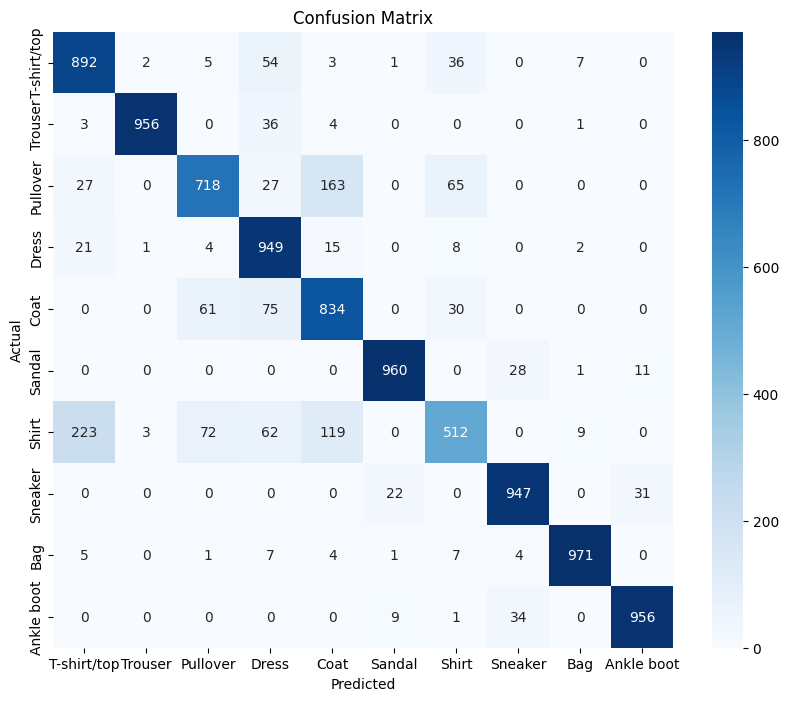

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import classification_report

print("\nClassification Report")
print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))


Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.89      0.82      1000
     Trouser       0.99      0.96      0.97      1000
    Pullover       0.83      0.72      0.77      1000
       Dress       0.78      0.95      0.86      1000
        Coat       0.73      0.83      0.78      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.78      0.51      0.62      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [61]:

model.save("fashion_mnist_mlp_model.h5")

print("\nModel saved successfully!")


Model saved successfully!
